Building a real-time object detection system using a pretrained deep learning model such as YOLO, This model should detect and classify multiple objects in images or video frames.

✅ Task Overview:<br>
1. Load a pretrained object detection model
2. Run detection on images or video
3. Draw bounding boxes around objects
4. Display class labels and confidence scores
5. Test on real-world images/video


In [28]:
# ============================================================
# CELL 1: IMPORT ALL REQUIRED LIBRARIES
# ============================================================

#core libraries
import os
import cv2
import time
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import glob

#additional libraries for object detection
from collections import Counter
from datetime import datetime
from ultralytics import YOLO
from IPython.display import Image, display

#remove warnings
import warnings
warnings.filterwarnings('ignore')

# Part 1: Pretrained YOLO object detection
we will use the pretrained model for different object detecion i.e, videos, images and real-time object detection through webcam without tarining them on custom data.

In [33]:
# ============================================================
# CELL 2: DEFINE PROJECT PATHS
# ============================================================

# Define input and output directories for images and videos, as well as the path to the pretrained YOLOv8 model.
INPUT_IMAGE_DIR = "input/images"
INPUT_VIDEO_DIR = "input/videos"

OUTPUT_IMAGE_DIR = "output/detected_images"
OUTPUT_VIDEO_DIR = "output/detected_videos"
LOG_DIR = "output/logs"

MODEL_PATH = "yolov8n.pt"

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)
os.makedirs(OUTPUT_VIDEO_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

print("Project paths loaded successfully.")

Project paths loaded successfully.


In [53]:
# ============================================================
# CELL 3: LOAD PRETRAINED YOLOv8 MODEL
# ============================================================

# Load the pretrained YOLOv8 model and retrieve the class names it can detect. This model is trained on the COCO dataset,
#  which includes 80 common object classes.

model = YOLO(MODEL_PATH)
class_names = model.names

print("Pretrained YOLOv8 model loaded successfully.")
print("This model detects common COCO objects such as:")

# YOLOv8 pretrained model is trained on COCO dataset.
# It can detect 80 common object classes.

for class_id, class_name in model.names.items():
    print(f"{class_id}: {class_name}")

Pretrained YOLOv8 model loaded successfully.
This model detects common COCO objects such as:
0: person
1: bicycle
2: car
3: motorcycle
4: airplane
5: bus
6: train
7: truck
8: boat
9: traffic light
10: fire hydrant
11: stop sign
12: parking meter
13: bench
14: bird
15: cat
16: dog
17: horse
18: sheep
19: cow
20: elephant
21: bear
22: zebra
23: giraffe
24: backpack
25: umbrella
26: handbag
27: tie
28: suitcase
29: frisbee
30: skis
31: snowboard
32: sports ball
33: kite
34: baseball bat
35: baseball glove
36: skateboard
37: surfboard
38: tennis racket
39: bottle
40: wine glass
41: cup
42: fork
43: knife
44: spoon
45: bowl
46: banana
47: apple
48: sandwich
49: orange
50: broccoli
51: carrot
52: hot dog
53: pizza
54: donut
55: cake
56: chair
57: couch
58: potted plant
59: bed
60: dining table
61: toilet
62: tv
63: laptop
64: mouse
65: remote
66: keyboard
67: cell phone
68: microwave
69: oven
70: toaster
71: sink
72: refrigerator
73: book
74: clock
75: vase
76: scissors
77: teddy bear
78: ha

In [36]:
# ============================================================
# CELL 4: HELPER FUNCTION TO SAVE DETECTION LOGS
# ============================================================

# This function takes the detection results, source name (image or video), and an optional log file name. 
# It extracts the class name, confidence score, and bounding box coordinates for each detected object and saves this
# information into a CSV file. If the log file already exists, it appends the new logs; otherwise, it creates a new file.

def save_detection_logs(results, source_name, log_file="detection_logs.csv"):
    """
    Saves detected object information into a CSV file.
    Stores class name, confidence score, bounding box values, and source name.
    """

    logs = []

    # Iterate through detection results and extract relevant information for logging
    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = class_names[class_id]
            confidence = float(box.conf[0])

            x1, y1, x2, y2 = box.xyxy[0].tolist()

            logs.append({
                "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "source": source_name,
                "class_name": class_name,
                "confidence": round(confidence, 4),
                "x1": round(x1, 2),
                "y1": round(y1, 2),
                "x2": round(x2, 2),
                "y2": round(y2, 2)
            })

    if logs:
        log_path = os.path.join(LOG_DIR, log_file)

        df = pd.DataFrame(logs)

        if os.path.exists(log_path):
            df.to_csv(log_path, mode="a", index=False, header=False)
        else:
            df.to_csv(log_path, index=False)

        print(f"Detection logs saved: {log_path}")
    else:
        print("No objects detected.")

In [37]:
# ============================================================
# CELL 5: HELPER FUNCTION TO COUNT OBJECTS
# ============================================================

# This function takes the detection results and counts how many times each object class is detected. It returns a dictionary
#  where the keys are the class names and the values are the counts of how many times each class was detected in the results.

def count_detected_objects(results):
    """
    Counts how many times each object class is detected.
    Returns a dictionary of object counts.
    """

    detected_classes = []

    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            detected_classes.append(class_names[class_id])

    return dict(Counter(detected_classes))

In [38]:
# ============================================================
# CELL 6: DETECT OBJECTS IN IMAGE
# ============================================================

# This function takes the path to an image, a confidence threshold, and an optional list of selected class IDs. 
# It uses the YOLOv8 model to detect objects in the image based on the specified confidence and class filters. 
# The detected objects are annotated on the image, which is then saved to the output directory. 
# The function also counts the detected objects and saves detailed detection logs into a CSV file. 
# Finally, it displays the annotated image and returns the path to the saved image along with the object counts.

def detect_image(image_path, confidence=0.25, selected_classes=None):
    """
    Detects objects in a single image.
    Supports confidence threshold and optional class filtering.
    Saves the detected image and detection logs.
    """

    results = model.predict(
        source=image_path,
        conf=confidence,
        classes=selected_classes,
        save=False
    )

    annotated_image = results[0].plot()

    image_name = os.path.basename(image_path)
    output_path = os.path.join(OUTPUT_IMAGE_DIR, f"detected_{image_name}")

    cv2.imwrite(output_path, annotated_image)

    object_counts = count_detected_objects(results)
    save_detection_logs(results, image_name)

    print("Image detection completed.")
    print("Saved output image:", output_path)
    print("Detected objects:", object_counts)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return output_path, object_counts


image 1/1 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\input\images\street.jpg: 448x640 14 persons, 2 bicycles, 4 motorcycles, 2 horses, 1 handbag, 71.5ms
Speed: 4.1ms preprocess, 71.5ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)
Detection logs saved: output/logs\detection_logs.csv
Image detection completed.
Saved output image: output/detected_images\detected_street.jpg
Detected objects: {'person': 14, 'motorcycle': 4, 'horse': 2, 'bicycle': 2, 'handbag': 1}


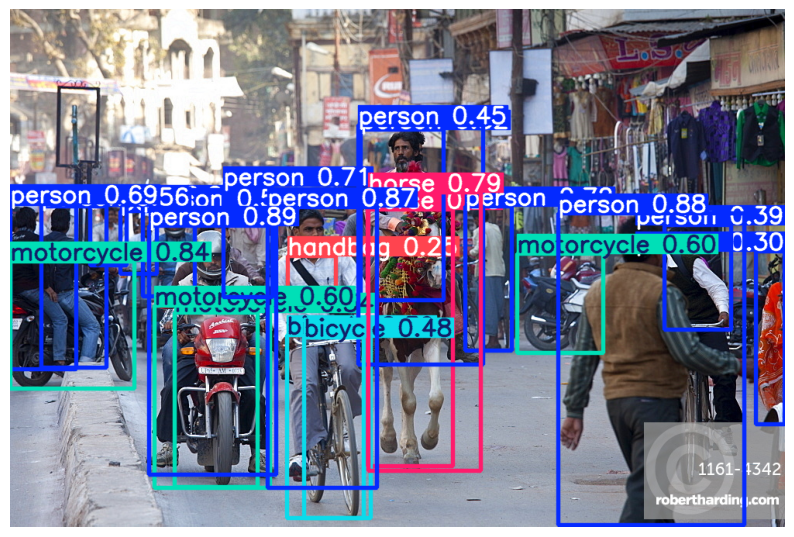

('output/detected_images\\detected_street.jpg',
 {'person': 14, 'motorcycle': 4, 'horse': 2, 'bicycle': 2, 'handbag': 1})

In [39]:
# ============================================================
# CELL 7: TEST IMAGE DETECTION
# ============================================================

# Test the object detection on a sample image. You can adjust the confidence threshold and select specific classes to detect.
image_path = "input/images/street.jpg"

detect_image(
    image_path=image_path,
    confidence=0.25
)


image 1/1 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\input\images\street.jpg: 448x640 11 persons, 61.2ms
Speed: 2.5ms preprocess, 61.2ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)
Detection logs saved: output/logs\detection_logs.csv
Image detection completed.
Saved output image: output/detected_images\detected_street.jpg
Detected objects: {'person': 11}


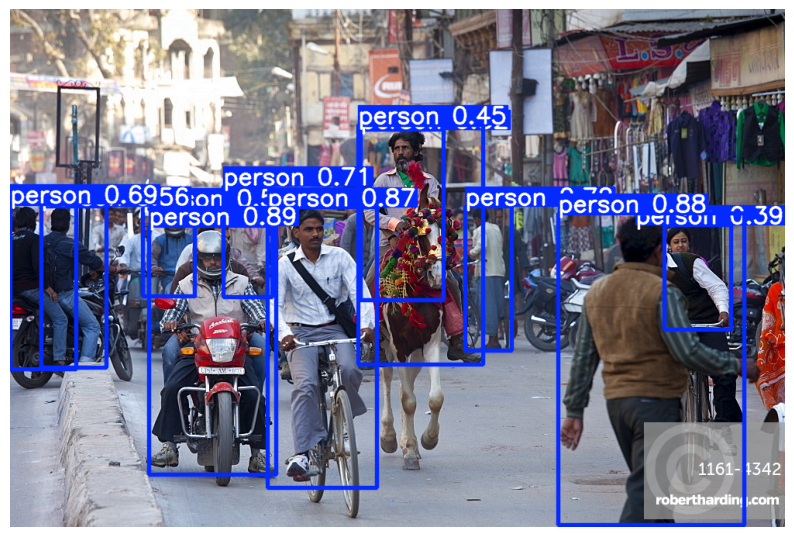

('output/detected_images\\detected_street.jpg', {'person': 11})

In [40]:
# ============================================================
# CELL 8: DETECT ONLY SPECIFIC CLASSES
# ============================================================


# This function takes a list of class names and converts them into their corresponding YOLO class IDs. 
# For example, if you want to detect only "person" and "car", 
# this function will return the class IDs for those classes based on the mapping provided by the YOLO model's class names.

def get_class_ids(class_list):
    """
    Converts class names into YOLO class IDs.
    Example: ['person', 'car'] -> [0, 2]
    """

    ids = []

    for class_name in class_list:
        for class_id, name in class_names.items():
            if name == class_name:
                ids.append(class_id)

    return ids



# Example: Detect only persons and cars

selected_class_ids = get_class_ids(["person", "car"])

detect_image(
    image_path="input/images/street.jpg",
    confidence=0.30,
    selected_classes=selected_class_ids
)

In [41]:
# ============================================================
# CELL 9: DETECT OBJECTS IN VIDEO AND SAVE OUTPUT
# ============================================================

# This function detects objects in a video frame by frame. 
# It saves the final detected video in the output directory and also saves detection logs into a CSV file. 
# The function uses OpenCV to read the video, applies the YOLOv8 model to each frame for object detection, 
# annotates the frames with detected objects, and writes the annotated frames to a new video file. 
# It also logs the detection details for each frame into a CSV file.

def detect_video(video_path, confidence=0.25, selected_classes=None):
    """
    Detects objects in a video frame by frame.
    Saves the final detected video in outputs/videos.
    Also saves detection logs into CSV.
    """

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    video_name = os.path.basename(video_path)
    output_path = os.path.join(OUTPUT_VIDEO_DIR, f"detected_{video_name}")

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_number = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_number += 1

        results = model.predict(
            source=frame,
            conf=confidence,
            classes=selected_classes,
            verbose=False
        )

        annotated_frame = results[0].plot()

        writer.write(annotated_frame)

        save_detection_logs(
            results,
            source_name=f"{video_name}_frame_{frame_number}"
        )

    cap.release()
    writer.release()

    print("Video detection completed.")
    print("Saved output video:", output_path)

    return output_path

In [44]:
# ============================================================
# CELL 10: TEST VIDEO DETECTION
# ============================================================

# Test the object detection on a sample video. You can adjust the confidence threshold and select specific classes to detect.
video_path = "input/videos/videoplayback.mp4"

detect_video(
    video_path=video_path,
    confidence=0.25
)

Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_logs.csv
Detection logs saved: output/logs\detection_lo

'output/detected_videos\\detected_videoplayback.mp4'

In [47]:
# ============================================================
# CELL 11: REAL-TIME WEBCAM OBJECT DETECTION
# ============================================================

#
def detect_webcam(confidence=0.25, selected_classes=None):
    """
    Runs real-time object detection using webcam.
    Press 'q' to stop the webcam detection window.
    """

    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Error: Webcam not found.")
        return

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        results = model.predict(
            source=frame,
            conf=confidence,
            classes=selected_classes,
            verbose=False
        )

        annotated_frame = results[0].plot()

        object_counts = count_detected_objects(results)

        y_position = 30
        for obj, count in object_counts.items():
            text = f"{obj}: {count}"
            cv2.putText(
                annotated_frame,
                text,
                (20, y_position),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 0),
                2
            )
            y_position += 30

        cv2.imshow("YOLOv8 Real-Time Object Detection", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

#uncomment the line below to run real-time webcam object detection. Adjust confidence and selected classes as needed.
#detect_webcam(confidence=0.30)

In [48]:
# ============================================================
# CELL 12: VIEW DETECTION LOGS
# ============================================================

log_path = "output/logs/detection_logs.csv"

if os.path.exists(log_path):
    logs_df = pd.read_csv(log_path)
    display(logs_df.head())
else:
    print("No detection logs found yet.")

,timestamp,source,class_name,confidence,x1,y1,x2,y2
0,2026-05-21 12:36:41,street.jpg,person,0.8893,179.98,279.53,343.60,600.01
1,2026-05-21 12:36:41,street.jpg,person,0.8798,707.37,263.26,947.27,665.07
2,2026-05-21 12:36:41,street.jpg,person,0.8737,332.94,255.45,473.68,617.95
3,2026-05-21 12:36:41,street.jpg,motorcycle,0.8400,0.31,325.60,160.57,489.71
4,2026-05-21 12:36:41,street.jpg,horse,0.7911,462.72,236.69,607.84,595.07


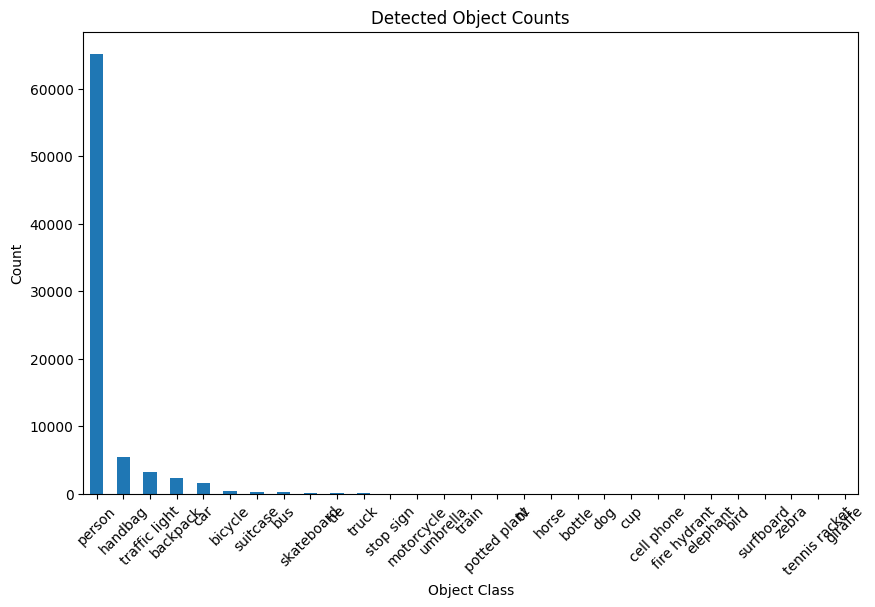

In [49]:
# ============================================================
# CELL 13: OBJECT COUNT VISUALIZATION
# ============================================================

def plot_object_counts(log_file="output/logs/detection_logs.csv"):
    """
    Creates a bar chart showing total detected objects from CSV logs.
    """

    if not os.path.exists(log_file):
        print("Log file not found.")
        return

    df = pd.read_csv(log_file)

    counts = df["class_name"].value_counts()

    plt.figure(figsize=(10, 6))
    counts.plot(kind="bar")
    plt.title("Detected Object Counts")
    plt.xlabel("Object Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()


plot_object_counts()

# Part 2: Custom kidney stone YOLO fine-tuning
we will use a custom dataset named kidney stone detection and trained the yolo model on that dataset.

In [5]:
# ============================================================
# PART 2 - CELL 1: CUSTOM DATASET PATHS
# ============================================================

CUSTOM_DATASET_DIR = "kidney_stone_dataset"
DATA_YAML_PATH = "kidney_stone_dataset/data.yaml"

CUSTOM_MODEL_NAME = "kidney_stone_yolo"
CUSTOM_MODEL_PATH = f"runs/detect/{CUSTOM_MODEL_NAME}/weights/best.pt"

print("Custom dataset path:", CUSTOM_DATASET_DIR)
print("Data YAML path:", DATA_YAML_PATH)

Custom dataset path: kidney_stone_dataset
Data YAML path: kidney_stone_dataset/data.yaml


In [6]:
# ============================================================
# PART 2 - CELL 2: CHECK CUSTOM DATASET STRUCTURE
# ============================================================

required_paths = [
    "kidney_stone_dataset/train/images",
    "kidney_stone_dataset/train/labels",
    "kidney_stone_dataset/valid/images",
    "kidney_stone_dataset/valid/labels",
    "kidney_stone_dataset/test/images",
    "kidney_stone_dataset/test/labels",
    "kidney_stone_dataset/data.yaml"
]

for path in required_paths:
    if os.path.exists(path):
        print(f"Found: {path}")
    else:
        print(f"Missing: {path}")

Found: kidney_stone_dataset/train/images
Found: kidney_stone_dataset/train/labels
Found: kidney_stone_dataset/valid/images
Found: kidney_stone_dataset/valid/labels
Found: kidney_stone_dataset/test/images
Found: kidney_stone_dataset/test/labels
Found: kidney_stone_dataset/data.yaml


In [8]:
# ============================================================
# PART 2 - CELL 3: TRAIN YOLOv8 ON CUSTOM DATASET
# ============================================================

custom_model = YOLO("yolov8n.pt")

custom_model.train(
    data=DATA_YAML_PATH,
    epochs=30,
    imgsz=640,
    batch=16,
    name=CUSTOM_MODEL_NAME,
    patience=8,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

Ultralytics 8.4.52  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1050 Ti with Max-Q Design, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=kidney_stone_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=kidney_stone_yolo-7, nbs=64, nms=False, opset=None, optimize=False, opt

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000027B35E21670>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [94]:
# ============================================================
# PART 2 - CELL 4: LOAD TRAINED CUSTOM MODEL
# ============================================================

# Load the trained custom model and print the class names it can detect. This will confirm that the model has been trained successfully 
# and is ready for inference on kidney stone detection.

kidney_model = YOLO("runs/detect/kidney_stone_yolo-7/weights/best.pt")

kidney_class_names = kidney_model.names

print("Custom kidney stone model loaded successfully.")
print("Classes:", kidney_class_names)

Custom kidney stone model loaded successfully.
Classes: {0: 'Tas_Var'}


In [95]:
# ============================================================
# PART 2 - CELL 5: VALIDATE CUSTOM MODEL
# ============================================================

# Validate the trained custom model on the validation dataset. This will provide metrics such as precision, recall, mAP, etc.,
# which will help evaluate the performance of the model on kidney stone detection.

metrics = kidney_model.val(
    data=DATA_YAML_PATH,
    imgsz=640,
    conf=0.25
)

print("Validation completed.")

Ultralytics 8.4.52  Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce GTX 1050 Ti with Max-Q Design, 4096MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 51.820.0 MB/s, size: 17.4 KB)
val: Scanning C:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\valid\labels.cache... 123 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 123/123  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.4it/s 3.3s0.4ss
                   all        123        325      0.839      0.675      0.664      0.268
Speed: 2.5ms preprocess, 8.3ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to C:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\runs\detect\val-5
Validation completed.


In [96]:
# ============================================================
# PART 2 - CELL 6: TEST CUSTOM MODEL ON TEST IMAGES
# ============================================================

# Run predictions on the test images using the trained custom model. This will save the detected images with annotations and 
# also return the detection results for further analysis.

test_results = kidney_model.predict(
    source="kidney_stone_dataset/test/images",
    conf=0.25,
    save=True
)

print("Custom model prediction completed.")

image 1/123 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-1-63703718086120120200001-5487554579919763006_png_jpg.rf.9fd67251e99a47dbe83a5db6efe6c016.jpg: 544x640 3 Tas_Vars, 46.3ms
image 2/123 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-1-63705534438365105500001-5275982036206127404_png_jpg.rf.365c4daf2b772012fe47e07b9daec86e.jpg: 544x640 1 Tas_Var, 41.0ms
image 3/123 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-1-63705540012666937300001-5673688970564737961_png_jpg.rf.15cca2fecc5f56865de3eb405476b90d.jpg: 544x640 1 Tas_Var, 33.5ms
image 4/123 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-1-63705542123217653900001-53052087674184


image 1/1 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-1-63703718086120120200001-5487554579919763006_png_jpg.rf.9fd67251e99a47dbe83a5db6efe6c016.jpg: 544x640 3 Tas_Vars, 41.5ms
Speed: 8.0ms preprocess, 41.5ms inference, 6.0ms postprocess per image at shape (1, 3, 544, 640)


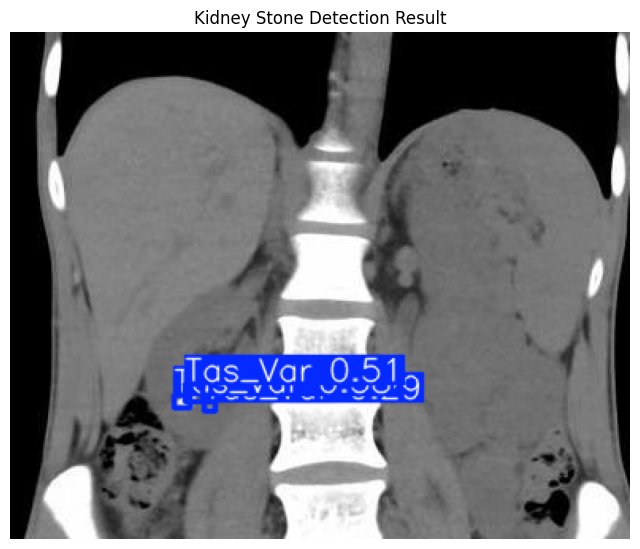

In [97]:
# ============================================================
# PART 2 - CELL 7: TEST CUSTOM MODEL ON SINGLE IMAGE
# ============================================================

# Test the custom kidney stone detection model on a single test image. 
# This will display the annotated image with detected kidney stones and print the detection results.

test_images = glob.glob("kidney_stone_dataset/test/images/*.jpg")

sample_image = test_images[0]

results = kidney_model.predict(
    source=sample_image,
    conf=0.25,
    save=False
)

annotated_image = results[0].plot()

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Kidney Stone Detection Result")
plt.show()

In [98]:
# ============================================================
# PART 2 - CELL 8: EXTRACT CUSTOM DETECTION DATA
# ============================================================

# Extract and print the detected class names, confidence scores, and bounding box coordinates from the prediction results.
for result in results:
    for box in result.boxes:
        class_id = int(box.cls[0])
        class_name = kidney_class_names[class_id]
        confidence = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        print(f"Class: {class_name}")
        print(f"Confidence: {confidence:.2f}")
        print(f"Box: {x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}")
        print("-" * 40)

Class: Tas_Var
Confidence: 0.51
Box: 110.5, 222.4, 121.6, 233.5
----------------------------------------
Class: Tas_Var
Confidence: 0.38
Box: 103.1, 229.6, 113.1, 237.2
----------------------------------------
Class: Tas_Var
Confidence: 0.29
Box: 122.7, 233.8, 129.5, 239.7
----------------------------------------


In [99]:
# ============================================================
# PART 2 - CELL 9: SAVE CUSTOM DETECTION LOGS
# ============================================================

# This function saves the detection results from the custom kidney stone model into a CSV file. 
# It handles cases where no detections are made and automatically creates the necessary folders for saving logs. 
# The logs include the timestamp, source name, detected class name, confidence score, and bounding box coordinates for each detection.

def save_custom_detection_logs(
    results,
    source_name,
    log_path="output/logs/kidney_stone_logs.csv"
):
    """
    Saves custom kidney stone detection results into CSV.
    Automatically creates folders and handles no detections.
    """

    # Create log folder automatically
    os.makedirs(os.path.dirname(log_path), exist_ok=True)

    logs = []

    for result in results:

        # Handle no detection case
        if len(result.boxes) == 0:

            logs.append({
                "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "source": source_name,
                "class_name": "no_detection",
                "confidence": 0.0,
                "x1": None,
                "y1": None,
                "x2": None,
                "y2": None
            })

        else:

            # Extract detection information
            for box in result.boxes:

                class_id = int(box.cls[0])
                class_name = kidney_class_names[class_id]

                confidence = float(box.conf[0])

                x1, y1, x2, y2 = box.xyxy[0].tolist()

                logs.append({
                    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                    "source": source_name,
                    "class_name": class_name,
                    "confidence": round(confidence, 4),
                    "x1": round(x1, 2),
                    "y1": round(y1, 2),
                    "x2": round(x2, 2),
                    "y2": round(y2, 2)
                })

    # Convert to DataFrame
    df = pd.DataFrame(logs)

    # Save CSV logs
    if os.path.exists(log_path):
        df.to_csv(
            log_path,
            mode="a",
            index=False,
            header=False
        )
    else:
        df.to_csv(
            log_path,
            index=False
        )

    print(f"Logs saved successfully: {log_path}")


# ============================================================
# TEST CUSTOM LOG SAVING
# ============================================================

results = kidney_model.predict(
    source=sample_image,
    conf=0.10,
    save=False
)

save_custom_detection_logs(
    results=results,
    source_name=os.path.basename(sample_image)
)


image 1/1 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-1-63703718086120120200001-5487554579919763006_png_jpg.rf.9fd67251e99a47dbe83a5db6efe6c016.jpg: 544x640 5 Tas_Vars, 55.6ms
Speed: 6.7ms preprocess, 55.6ms inference, 12.1ms postprocess per image at shape (1, 3, 544, 640)
Logs saved successfully: output/logs/kidney_stone_logs.csv


In [100]:
# ============================================================
# PART 2 - CELL 10: COUNT CUSTOM OBJECTS
# ============================================================
# This function counts detected kidney stone objects from the prediction results. It iterates through the detection results,
# extracts the class names of the detected objects, and counts how many times each class is detected. 
# It returns a dictionary where the keys are the class names and the values are the counts of detected objects.

test_images = glob.glob("kidney_stone_dataset/test/images/*.jpg")

for image_path in test_images:
    results = kidney_model.predict(
        source=image_path,
        conf=0.10,
        save=False
    )

    save_custom_detection_logs(
        results=results,
        source_name=os.path.basename(image_path)
    )

print("Logs saved for all test images.")


image 1/1 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-1-63703718086120120200001-5487554579919763006_png_jpg.rf.9fd67251e99a47dbe83a5db6efe6c016.jpg: 544x640 5 Tas_Vars, 37.1ms
Speed: 4.4ms preprocess, 37.1ms inference, 5.4ms postprocess per image at shape (1, 3, 544, 640)
Logs saved successfully: output/logs/kidney_stone_logs.csv

image 1/1 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-1-63705534438365105500001-5275982036206127404_png_jpg.rf.365c4daf2b772012fe47e07b9daec86e.jpg: 544x640 3 Tas_Vars, 31.8ms
Speed: 5.4ms preprocess, 31.8ms inference, 6.3ms postprocess per image at shape (1, 3, 544, 640)
Logs saved successfully: output/logs/kidney_stone_logs.csv

image 1/1 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\images\1-3-46-670589-33-

Log file loaded successfully.
Total rows: 472
Columns: ['timestamp', 'source', 'class_name', 'confidence', 'x1', 'y1', 'x2', 'y2']


,timestamp,source,class_name,confidence,x1,y1,x2,y2
0,2026-05-21 15:50:26,1-3-46-670589-33-1-63703718086120120200001-548...,no_detection,0.0,NaN,NaN,NaN,NaN
1,2026-05-21 15:51:24,1-3-46-670589-33-1-63703718086120120200001-548...,no_detection,0.0,NaN,NaN,NaN,NaN
2,2026-05-21 15:53:31,1-3-46-670589-33-1-63703718086120120200001-548...,no_detection,0.0,NaN,NaN,NaN,NaN
3,2026-05-21 15:53:31,1-3-46-670589-33-1-63705534438365105500001-527...,no_detection,0.0,NaN,NaN,NaN,NaN
4,2026-05-21 15:53:31,1-3-46-670589-33-1-63705540012666937300001-567...,no_detection,0.0,NaN,NaN,NaN,NaN


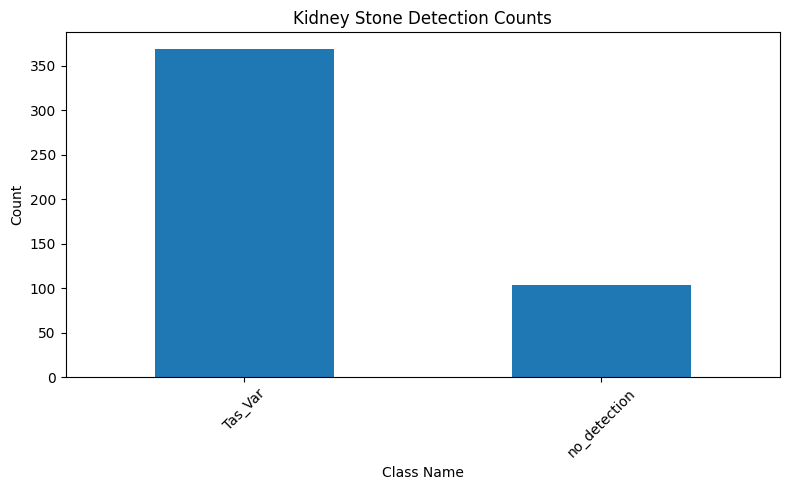

In [101]:
# ============================================================
# PART 2 - CELL 11: PLOT CUSTOM DETECTION COUNTS
# ============================================================

def plot_custom_detection_counts(log_path="output/logs/kidney_stone_logs.csv"):
    """
    Plots detected kidney stone class counts from detection logs.
    """

    if not os.path.exists(log_path):
        print(f"Log file not found at: {log_path}")
        return

    df = pd.read_csv(log_path)

    print("Log file loaded successfully.")
    print("Total rows:", len(df))
    print("Columns:", df.columns.tolist())
    display(df.head())

    if df.empty:
        print("Log file is empty. Run detection first to generate logs.")
        return

    if "class_name" not in df.columns:
        print("Column 'class_name' not found in log file.")
        return

    counts = df["class_name"].dropna().value_counts()

    if counts.empty:
        print("No detected class names found in the log file.")
        return

    plt.figure(figsize=(8, 5))
    counts.plot(kind="bar")
    plt.title("Kidney Stone Detection Counts")
    plt.xlabel("Class Name")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_custom_detection_counts()


image 1/1 c:\Users\Saif Ullah\Intern_at_Hasnain_Karimain_Software_House\17_object_detection_yolo\kidney_stone_dataset\test\test.jpg: 640x640 2 Tas_Vars, 36.0ms
Speed: 6.0ms preprocess, 36.0ms inference, 6.6ms postprocess per image at shape (1, 3, 640, 640)


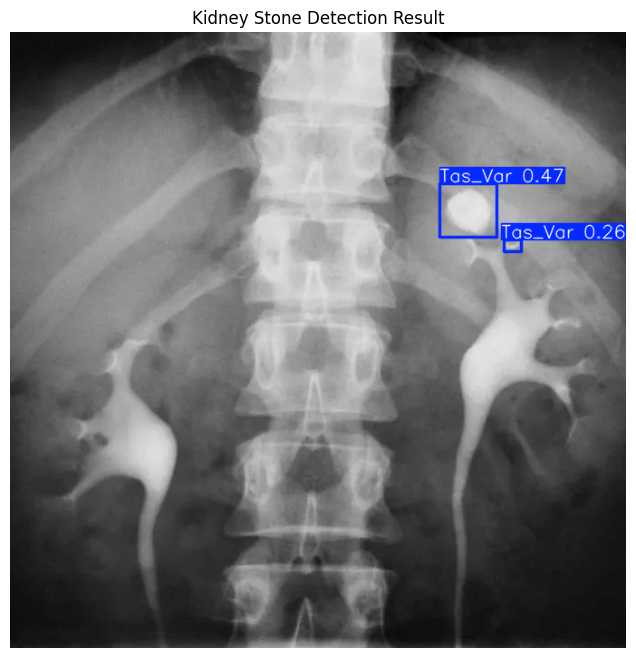

Detected image saved at: output/kidney_stone_predictions/detected_real_image.jpg
Class: Tas_Var
Confidence: 0.47
Bounding Box: 474.4, 167.1, 537.5, 226.9
----------------------------------------
Class: Tas_Var
Confidence: 0.26
Bounding Box: 545.4, 229.4, 564.5, 242.2
----------------------------------------


In [102]:
# ============================================================
# FINAL TEST: CUSTOM KIDNEY STONE MODEL ON ONE REAL IMAGE
# ============================================================

# Load trained custom model
model_path = "runs/detect/kidney_stone_yolo-7/weights/best.pt"
kidney_model = YOLO(model_path)

# Add your real image path here
image_path = "kidney_stone_dataset/test/test.jpg"

# Run prediction
results = kidney_model.predict(
    source=image_path,
    conf=0.25,
    save=False
)

# Show detected image
annotated_image = results[0].plot()

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Kidney Stone Detection Result")
plt.show()

# Save output image
os.makedirs("output/kidney_stone_predictions", exist_ok=True)

output_image_path = "output/kidney_stone_predictions/detected_real_image.jpg"
cv2.imwrite(output_image_path, annotated_image)

print("Detected image saved at:", output_image_path)

# Print detection details
for result in results:
    if len(result.boxes) == 0:
        print("No kidney stone detected.")
    else:
        for box in result.boxes:
            class_id = int(box.cls[0])
            class_name = kidney_model.names[class_id]
            confidence = float(box.conf[0])
            x1, y1, x2, y2 = box.xyxy[0].tolist()

            print(f"Class: {class_name}")
            print(f"Confidence: {confidence:.2f}")
            print(f"Bounding Box: {x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}")
            print("-" * 40)